# Modeling — Swing LR (`is_swing`)

Logistic-regression **control model** for swing probability. Matches the RF swing notebook feature groups and 3-way split so lift is directly comparable.

**Prerequisites:** `03_feature_engineering.ipynb`

**Input:** `data/modeling_frame_2025.parquet`

Production counterpart: **`05_modeling_swing_rf.ipynb`**.

## 1. Target definition

**Target:** `is_swing` (binary) — already encoded in the modeling frame.

Swings include whiffs, fouls, and balls in play; takes include called strikes, balls, HBP, etc.

## Architecture — apples-to-apples control for RF models

These **logistic / linear baselines** use the **same feature space, pitch-type schema, and chronological split** as the production Random Forest pipeline (`05`, `07`, `09`).

| Split | Dates | Purpose |
|-------|-------|---------|
| **Train** | Mar–Jul 2025 (`game_date < 2025-08-01`) | Fit models |
| **Validation** | Aug 2025 | Forward feature-group selection only |
| **Test** | Sep 2025 | Locked holdout — final metrics once |

**Batter signal:** season-to-date rolling metrics (`swing_pct`, `whiff_pct`, `z_swing_pct`, `o_swing_pct`, `z_whiff_pct`, `o_whiff_pct`) — no `batter_id` or `batter_te`.

**Platoon:** `same_handed`

**Pitch physics (three groups):** `pitch_movement` (`norm_hb`, `norm_ivb`) → `pitcher_delivery` (release point, extension, `p_throws_L`) → `pitch_quality` (`release_speed`, `release_spin_rate`).

**Pitch types:** all **10** competitive Statcast codes (`COMPETITIVE_PITCH_TYPES`) via one-hot `pitch_*` columns.

**Swing definition:** full swings only — `foul_bunt` and `missed_bunt` are takes, not swings.


## 2. Process

| Step | Choice |
|------|--------|
| **Baseline features** | `is_in_zone`, `miss_dist_in`, `center_dist_in` |
| **Candidate groups** | `pitch_type` → `pitch_quality` → `count` → `batter_rolling` → `pitch_movement` → `pitcher_delivery` → `attack_zone` → `base_state` → `platoon` |
| **Excluded** | Bat-tracking metrics — swing uses pitch/count/hitter tendency only |
| **Model** | Logistic regression (`class_weight=balanced`), numeric features scaled |
| **Selection metric** | **August validation log-loss**; keep if gain ≥ **MIN_GAIN (0.0010)** |
| **Group order** | High-signal sequence (see architecture note above) |
| **Final evaluation** | Refit on train with selected groups; score **September test** once |

Logic: `src/swing_modeling.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

NB_DIR = Path.cwd().resolve()
ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

MODELING_FILE = ROOT / "data" / "modeling_frame_2025.parquet"
if not MODELING_FILE.exists():
    raise FileNotFoundError(
        f"Run 03_feature_engineering.ipynb first — missing {MODELING_FILE}"
    )

import importlib
import src.feature_engineering as feature_engineering
import src.swing_modeling as swing_modeling

importlib.reload(feature_engineering)
importlib.reload(swing_modeling)

from src.swing_modeling import (
    BASELINE_FEATURES,
    FEATURE_GROUP_ORDER,
    FEATURE_GROUPS,
    TARGET,
    TRAIN_END,
    VAL_END,
    calibration_bins,
    chronological_split,
    coefficient_frame,
    forward_select_feature_groups,
    results_table,
    roc_curve_data,
    swing_target_definition,
    train_master_model,
)

frame = pd.read_parquet(MODELING_FILE)
train, val, test = chronological_split(frame)

display(Markdown(swing_target_definition()))
print(f"Pitches — train: {len(train):,} | val: {len(val):,} | test: {len(test):,}")
print(f"Swing rate — train: {train[TARGET].mean():.1%} | val: {val[TARGET].mean():.1%} | test: {test[TARGET].mean():.1%}")
print(f"Train: Mar–Jul (< {TRAIN_END.date()}) | Val: Aug | Test: Sep (>= {VAL_END.date()})")


is_swing = 1 when Statcast description is a full swing (foul, foul_tip, hit_into_play, hit_into_play_no_out, hit_into_play_score, swinging_strike, swinging_strike_blocked); else 0. Bunt attempts (foul_bunt, missed_bunt) are **not** swings.

Pitches — train: 465,254 | val: 121,999 | test: 108,369
Swing rate — train: 47.6% | val: 47.5% | test: 47.8%
Train: Mar–Jul (< 2025-08-01) | Val: Aug | Test: Sep (>= 2025-09-01)


## 3. Baseline & candidate groups

In [2]:
print("Baseline features:", BASELINE_FEATURES)
print("\nCandidate groups (added one at a time; no bat_tracking):")
for name in FEATURE_GROUP_ORDER:
    print(f"  • {name}: {len(FEATURE_GROUPS[name])} columns")
    if name in ("batter_rolling", "bat_tracking", "pitch_movement", "pitcher_delivery", "pitch_quality"):
        print(f"      {FEATURE_GROUPS[name]}")


Baseline features: ['is_in_zone', 'miss_dist_in', 'center_dist_in']

Candidate groups (added one at a time; no bat_tracking):
  • pitch_type: 10 columns
  • pitch_quality: 2 columns
      ['release_speed', 'release_spin_rate']
  • count: 12 columns
  • batter_rolling: 6 columns
      ['swing_pct', 'whiff_pct', 'z_swing_pct', 'o_swing_pct', 'z_whiff_pct', 'o_whiff_pct']
  • pitch_movement: 2 columns
      ['norm_hb', 'norm_ivb']
  • pitcher_delivery: 5 columns
      ['release_pos_x', 'release_pos_y', 'release_pos_z', 'release_extension', 'p_throws_L']
  • attack_zone: 4 columns
  • base_state: 8 columns
  • platoon: 1 columns


## 4. Forward selection (August) + final test evaluation (September)

Feature groups are greedily added using **validation** log-loss only. After selection, the final feature set is refit on **train** and evaluated once on **test**.

In [3]:
MIN_GAIN = 0.0010

print(f"Minimum gain threshold: {MIN_GAIN:.4f} log-loss\n")
report = forward_select_feature_groups(
    train,
    val,
    min_log_loss_gain=MIN_GAIN,
    verbose=True,
)

baseline_master = train_master_model(train, test, BASELINE_FEATURES, name="baseline (Sep test)")
master = train_master_model(train, test, report.final.features, name="final (Sep test)")

print("\nSelected groups:", report.selected_groups or "(baseline only)")
print(f"Final feature count: {len(report.final.features)}")
print(
    f"Baseline test — log-loss: {baseline_master.test_log_loss:.4f} | "
    f"ROC-AUC: {baseline_master.test_roc_auc:.3f} | "
    f"Brier: {baseline_master.test_brier:.4f}"
)
print(
    f"Final test — log-loss: {master.test_log_loss:.4f} | "
    f"ROC-AUC: {master.test_roc_auc:.3f} | "
    f"Brier: {master.test_brier:.4f}"
)

display(results_table(report))


Minimum gain threshold: 0.0010 log-loss

Baseline — val log-loss: 0.5818 (3 features)
  pitch_type: Kept (log-loss gain = +0.0068, val log-loss = 0.5750, 13 features)
  pitch_quality: Kept (log-loss gain = +0.0012, val log-loss = 0.5738, 15 features)
  count: Kept (log-loss gain = +0.0541, val log-loss = 0.5197, 27 features)
  batter_rolling: Kept (log-loss gain = +0.0070, val log-loss = 0.5127, 33 features)
  pitch_movement: Dropped due to insufficient gain (< 0.0010) (log-loss gain = +0.0000)
  pitcher_delivery: Dropped due to insufficient gain (< 0.0010) (log-loss gain = +0.0000)
  attack_zone: Dropped due to insufficient gain (< 0.0010) (log-loss gain = +0.0002)
  base_state: Dropped due to insufficient gain (< 0.0010) (log-loss gain = +0.0007)
  platoon: Dropped due to insufficient gain (< 0.0010) (log-loss gain = +0.0000)

Selected groups: ['pitch_type', 'pitch_quality', 'count', 'batter_rolling']
Final feature count: 33
Baseline test — log-loss: 0.5842 | ROC-AUC: 0.753 | Brier: 

,step,added_group,kept,n_features,val_log_loss,val_roc_auc,delta_log_loss
0,baseline,NaN,yes,3,0.5818,0.755,+0.0000
1,pitch_type,pitch_type,yes,13,0.5750,0.763,+0.0068
2,pitch_quality,pitch_quality,yes,15,0.5738,0.765,+0.0012
3,count,count,yes,27,0.5197,0.821,+0.0541
4,batter_rolling,batter_rolling,yes,33,0.5127,0.827,+0.0070
5,pitch_movement,pitch_movement,no,35,0.5126,0.827,+0.0000
6,pitcher_delivery,pitcher_delivery,no,38,0.5126,0.827,+0.0000
7,attack_zone,attack_zone,no,37,0.5125,0.827,+0.0002
8,base_state,base_state,no,41,0.5120,0.827,+0.0007
9,platoon,platoon,no,34,0.5126,0.827,+0.0000


## 5. Visuals

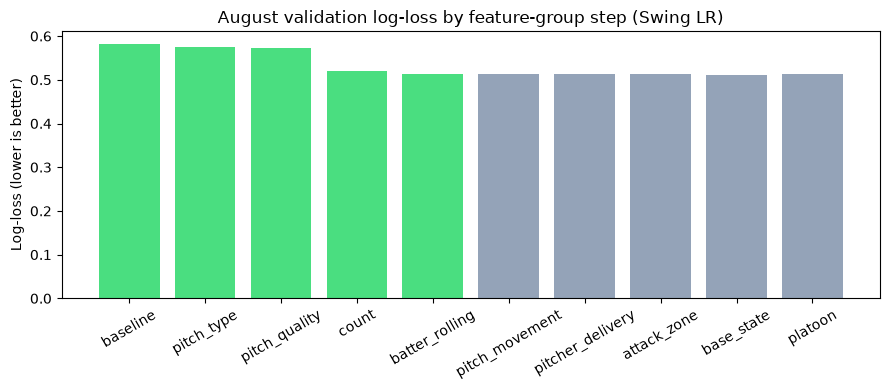

In [4]:
steps_df = pd.DataFrame(report.steps)
colors = ["#4ade80" if kept else "#94a3b8" for kept in steps_df["kept"]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(steps_df["step"], steps_df["val_log_loss"], color=colors)
ax.set_title("August validation log-loss by feature-group step (Swing LR)")
ax.set_ylabel("Log-loss (lower is better)")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()


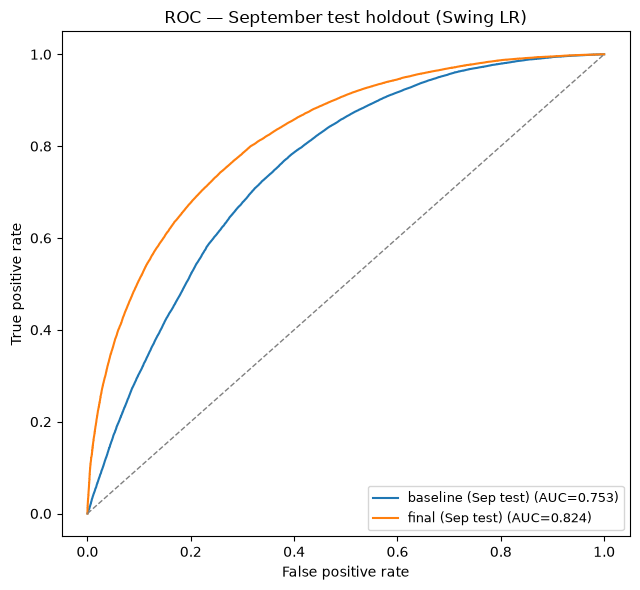

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for result in [baseline_master, master]:
    fpr, tpr = roc_curve_data(result)
    ax.plot(fpr, tpr, label=f"{result.name} (AUC={result.test_roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
ax.set_title("ROC — September test holdout (Swing LR)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()


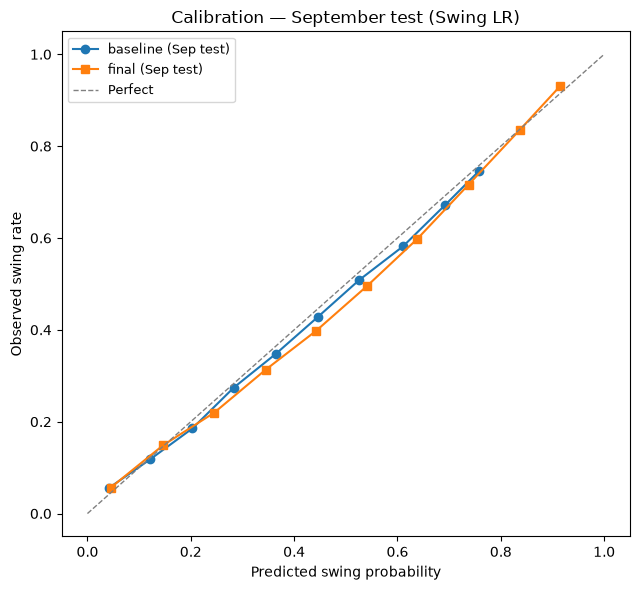

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for result, style in [(baseline_master, "o-"), (master, "s-")]:
    cal = calibration_bins(result.y_test, result.y_prob_test)
    ax.plot(cal["pred_mean"], cal["obs_rate"], style, label=result.name)
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Perfect")
ax.set_title("Calibration — September test (Swing LR)")
ax.set_xlabel("Predicted swing probability")
ax.set_ylabel("Observed swing rate")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()


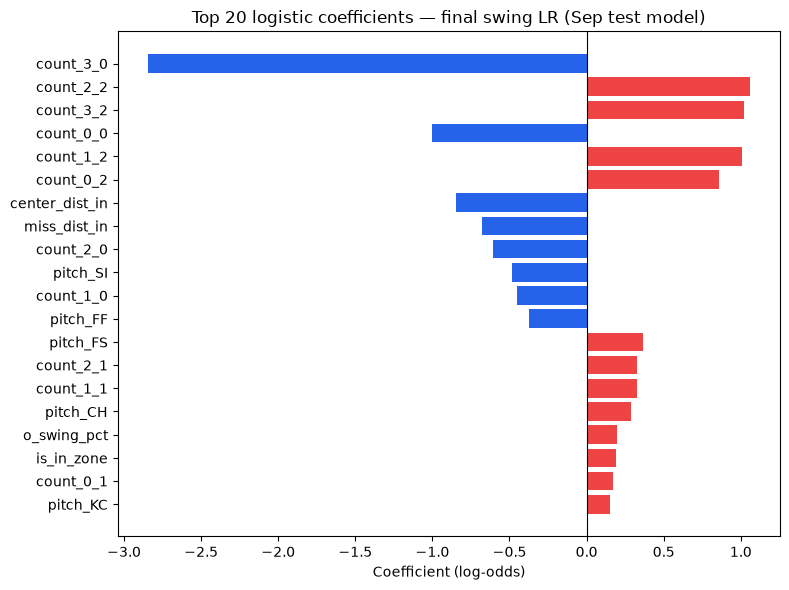

,feature,coefficient,abs_coef
0,count_3_0,-2.845281,2.845281
1,count_2_2,1.058871,1.058871
2,count_3_2,1.022749,1.022749
3,count_0_0,-1.005731,1.005731
4,count_1_2,1.005234,1.005234
5,count_0_2,0.858195,0.858195
6,center_dist_in,-0.844526,0.844526
7,miss_dist_in,-0.677313,0.677313
8,count_2_0,-0.607259,0.607259
9,pitch_SI,-0.484024,0.484024


In [7]:
coef = coefficient_frame(master).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#ef4444" if c > 0 else "#2563eb" for c in coef["coefficient"]]
ax.barh(coef["feature"][::-1], coef["coefficient"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 logistic coefficients — final swing LR (Sep test model)")
ax.set_xlabel("Coefficient (log-odds)")
fig.tight_layout()
plt.show()

display(coef)


## 6. Summary

Re-run this notebook after updating `03_feature_engineering.ipynb` or the baseline module. Compare **September test** metrics directly to **`05_modeling_swing_rf.ipynb`**.

Next: **`05_modeling_swing_rf.ipynb`**, then **`06_modeling_whiff_lr.ipynb`**.